# **QUESTION 10**

In [1]:
import numpy as np

In [3]:
prices = np . array ([
[100 , 108 , 103 , 115 , 110 , 119 , 125 , 121 , 130 , 127 , 135 , 140] ,

[200 , 195 , 210 , 205 , 220 , 215 , 225 , 230 , 222 , 235 , 240 , 238]
])

returns = (prices[:,1:] - prices[:,:-1]) / prices[:,:-1]

print(returns)
print(returns.shape)

[[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]
(2, 11)


In [7]:
monthly_mean=np.mean(returns, axis=1)
annual_mean = monthly_mean * 12
monthly_std = np.std(returns, axis=1, ddof=1)
annual_std = monthly_std * np.sqrt(12)
print("Annualised Mean Returns:")
print(annual_mean)

print("\nAnnualised Standard Deviations:")
print(annual_std)

Annualised Mean Returns:
[0.39087388 0.20073826]

Annualised Standard Deviations:
[0.20199403 0.14582022]


In [8]:
cov_matrix = np.cov(returns)

print(cov_matrix)

[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]


the off diagnol entries are equal and the respective 1x1 and 2x2 entries are variance of a and b.

# **Question** **11**

In [11]:
import numpy as np

# Expected returns
mu = np.array([0.15, 0.08, 0.05])

# Covariance matrix from Q6
Sigma = np.array([
    [0.0625, 0.012,   0.001],
    [0.012,  0.0144,  0.00096],
    [0.001,  0.00096, 0.0016]
])
w = np.array([1/3, 1/3, 1/3])

# Portfolio expected return
portfolio_return = w @ mu

# Portfolio variance
portfolio_variance = w @ Sigma @ w

# Portfolio volatility
portfolio_std = np.sqrt(portfolio_variance)

print("Part (a)")
print("Portfolio Expected Return =", portfolio_return)
print("Portfolio Variance =", portfolio_variance)
print("Portfolio Volatility =", portfolio_std)


Part (a)
Portfolio Expected Return = 0.09333333333333332
Portfolio Variance = 0.011824444444444443
Portfolio Volatility = 0.10874026137748816


In [12]:
weights = np.random.dirichlet(np.ones(3), size=10000)

# Portfolio returns for all portfolios
portfolio_returns = weights @ mu

# Portfolio variances for all portfolios
portfolio_variances = np.sum((weights @ Sigma) * weights, axis=1)

# Portfolio volatilities
portfolio_std = np.sqrt(portfolio_variances)

print("\nPart (b)")
print("Shape of portfolio returns:", portfolio_returns.shape)
print("Shape of portfolio volatilities:", portfolio_std.shape)


Part (b)
Shape of portfolio returns: (10000,)
Shape of portfolio volatilities: (10000,)


In [13]:
Rf = 0.03  # Risk-free rate

# Sharpe ratios for all portfolios
sharpe_ratios = (portfolio_returns - Rf) / portfolio_std

# Maximum Sharpe Ratio
max_index = np.argmax(sharpe_ratios)

max_sharpe = sharpe_ratios[max_index]

optimal_weights = weights[max_index]

print("\nPart (c)")
print("Maximum Sharpe Ratio =", max_sharpe)

print("\nOptimal Portfolio Weights:")
print(optimal_weights)


Part (c)
Maximum Sharpe Ratio = 0.6817770821417144

Optimal Portfolio Weights:
[0.1013635  0.11364034 0.78499615]


# Question 12

In [14]:
import numpy as np

# Asset parameters
mu1 = 0.12
sigma1 = 0.20

mu2 = 0.06
sigma2 = 0.10

# Portfolio weights
w1 = 0.6
w2 = 0.4

# Correlation values
rho = np.linspace(-1, 1, 200)

# Portfolio variance
portfolio_variance = (
    (w1**2)*(sigma1**2)
    + (w2**2)*(sigma2**2)
    + 2*w1*w2*rho*sigma1*sigma2
)

# Portfolio volatility
portfolio_std = np.sqrt(portfolio_variance)

# Minimum volatility
min_index = np.argmin(portfolio_std)

min_rho = rho[min_index]

min_sigma = portfolio_std[min_index]

print("Correlation giving minimum volatility:", min_rho)

print("Minimum portfolio volatility:", min_sigma)

Correlation giving minimum volatility: -1.0
Minimum portfolio volatility: 0.08000000000000002


# Question 13

In [16]:
import pandas as pd
import numpy as np

# Simulated data
np.random.seed(0)

dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')

mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])

sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])

returns_sim = np.random.normal(
    mu_weekly,
    sig_weekly,
    (52, 4)
)

prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)

df = pd.DataFrame(
    prices_sim,
    index=dates,
    columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)
returns = df.pct_change().dropna()

print(returns.head(3))

print("Shape:", returns.shape)

                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842
Shape: (51, 4)


In [17]:
summary = returns.describe()

print(summary)

highest_mean_asset = returns.mean().idxmax()

highest_std_asset = returns.std().idxmax()

print("Highest Mean Return:", highest_mean_asset)

print("Highest Standard Deviation:", highest_std_asset)


            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -0.000365   0.009468
75%     0.039082   0.028178   0.009462   0.020051
max     0.098326   0.060309   0.044265   0.050269
Highest Mean Return: AMZN
Highest Standard Deviation: AAPL


In [18]:
Rf = 0.02

annual_return = returns.mean() * 52

annual_std = returns.std() * np.sqrt(52)

sharpe_ratios = (annual_return - Rf) / annual_std

print("Annualised Sharpe Ratios:")

print(sharpe_ratios)

Annualised Sharpe Ratios:
AAPL     0.824485
MSFT     0.397113
GOOGL   -0.537553
AMZN     1.794045
dtype: float64


# Question 14

In [19]:
import pandas as pd
import numpy as np
correlation_matrix = returns.corr()

print(correlation_matrix)

# Remove diagonal values
corr_no_diag = correlation_matrix.where(
    ~np.eye(correlation_matrix.shape[0], dtype=bool)
)

# Lowest correlation pair
lowest_corr = corr_no_diag.min().min()

pair = corr_no_diag.stack().idxmin()

print("\nLowest Correlation:", lowest_corr)

print("Asset Pair:", pair)

           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000

Lowest Correlation: -0.07532396170747635
Asset Pair: ('AAPL', 'MSFT')


In [20]:
weights = pd.Series(
    [0.25, 0.25, 0.25, 0.25],
    index=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

portfolio_returns = returns.dot(weights)

print("\nPortfolio Return Series:")

print(portfolio_returns.head())


Portfolio Return Series:
2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64


In [21]:
monthly_returns = (
    portfolio_returns
    .resample('ME')
    .apply(lambda x: (1 + x).prod() - 1)
)

monthly_mean = monthly_returns.mean()

monthly_std = monthly_returns.std()

print("\nMean Monthly Return:", monthly_mean)

print("Monthly Standard Deviation:", monthly_std)


Mean Monthly Return: 0.013974973306651484
Monthly Standard Deviation: 0.039023369077949295


# Question 15

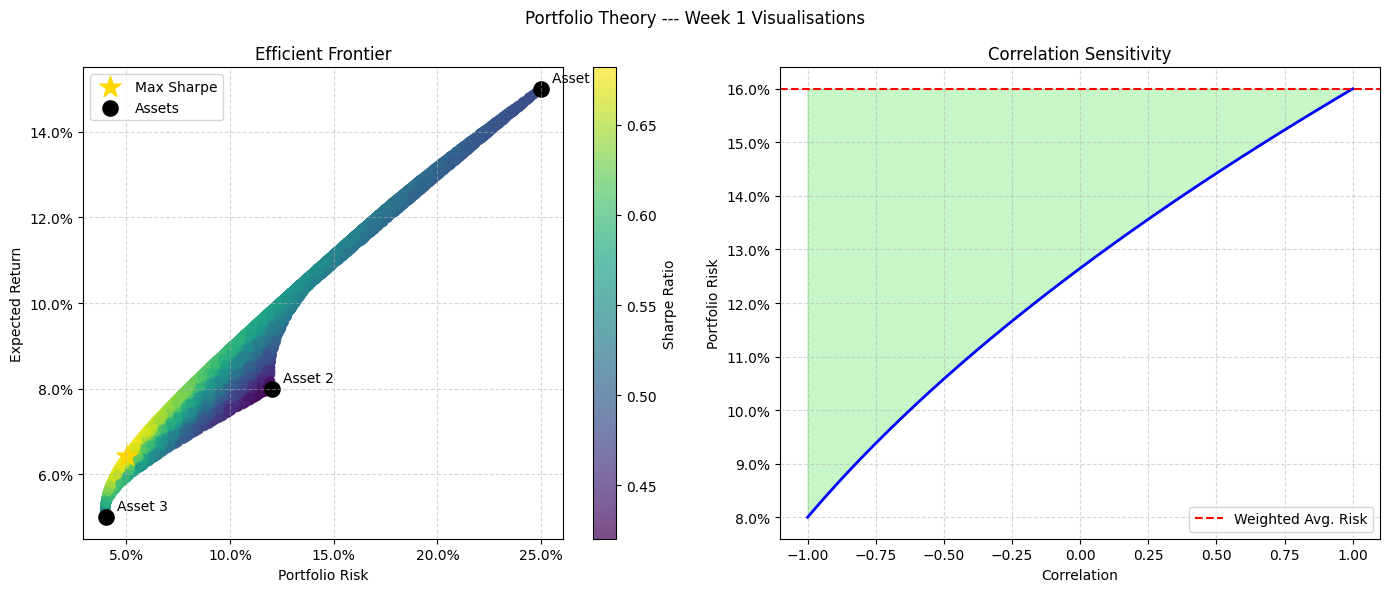

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ---------------------------------------------------
# 3-Asset Parameters
# ---------------------------------------------------

mu = np.array([0.15, 0.08, 0.05])

Sigma = np.array([
    [0.0625, 0.012,   0.001],
    [0.012,  0.0144,  0.00096],
    [0.001,  0.00096, 0.0016]
])

tickers = ['Asset 1', 'Asset 2', 'Asset 3']

# ---------------------------------------------------
# Simulate 20,000 Portfolios
# ---------------------------------------------------

np.random.seed(0)

weights = np.random.dirichlet(np.ones(3), size=20000)

portfolio_returns = weights @ mu

portfolio_variances = np.sum((weights @ Sigma) * weights, axis=1)

portfolio_std = np.sqrt(portfolio_variances)

Rf = 0.03

sharpe_ratios = (portfolio_returns - Rf) / portfolio_std

# Maximum Sharpe portfolio
max_index = np.argmax(sharpe_ratios)

max_return = portfolio_returns[max_index]

max_std = portfolio_std[max_index]

# ---------------------------------------------------
# Create Figure
# ---------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ===================================================
# Left Plot — Efficient Frontier
# ===================================================

scatter = axes[0].scatter(
    portfolio_std,
    portfolio_returns,
    c=sharpe_ratios,
    cmap='viridis',
    alpha=0.7
)

# Max Sharpe portfolio
axes[0].scatter(
    max_std,
    max_return,
    color='gold',
    marker='*',
    s=250,
    label='Max Sharpe'
)

# Individual assets
asset_std = np.sqrt(np.diag(Sigma))

axes[0].scatter(
    asset_std,
    mu,
    color='black',
    s=120,
    label='Assets'
)

# Asset labels
for i, ticker in enumerate(tickers):
    axes[0].annotate(
        ticker,
        (asset_std[i], mu[i]),
        textcoords="offset points",
        xytext=(8,5)
    )

axes[0].set_title('Efficient Frontier')

axes[0].set_xlabel('Portfolio Risk')

axes[0].set_ylabel('Expected Return')

axes[0].grid(True, linestyle='--', alpha=0.5)

axes[0].legend()

axes[0].xaxis.set_major_formatter(PercentFormatter(1))

axes[0].yaxis.set_major_formatter(PercentFormatter(1))

cbar = fig.colorbar(scatter, ax=axes[0])

cbar.set_label('Sharpe Ratio')

# ===================================================
# Right Plot — Correlation Sensitivity
# ===================================================

sigma1 = 0.20
sigma2 = 0.10

w1 = 0.6
w2 = 0.4

rho = np.linspace(-1, 1, 200)

portfolio_variance_2 = (
    (w1**2)*(sigma1**2)
    + (w2**2)*(sigma2**2)
    + 2*w1*w2*rho*sigma1*sigma2
)

portfolio_std_2 = np.sqrt(portfolio_variance_2)

axes[1].plot(
    rho,
    portfolio_std_2,
    color='blue',
    linewidth=2
)

weighted_avg_risk = w1*sigma1 + w2*sigma2

axes[1].axhline(
    weighted_avg_risk,
    color='red',
    linestyle='--',
    label='Weighted Avg. Risk'
)

axes[1].fill_between(
    rho,
    portfolio_std_2,
    weighted_avg_risk,
    where=(portfolio_std_2 < weighted_avg_risk),
    color='lightgreen',
    alpha=0.5
)

axes[1].set_title('Correlation Sensitivity')

axes[1].set_xlabel('Correlation')

axes[1].set_ylabel('Portfolio Risk')

axes[1].grid(True, linestyle='--', alpha=0.5)

axes[1].legend()

axes[1].yaxis.set_major_formatter(PercentFormatter(1))

# ---------------------------------------------------
# Global Figure Settings
# ---------------------------------------------------

fig.suptitle('Portfolio Theory --- Week 1 Visualisations')

plt.tight_layout()

plt.savefig('week1_plots.png', dpi=150)

plt.show()